In [1]:
import os
import json
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
with open("data_split.json", "r") as f:
    split_data = json.load(f)

train_subjects = split_data["train"]
val_subjects = split_data["validation"]
test_subjects = split_data["test"]

print("Train:", len(train_subjects))
print("Validation:", len(val_subjects))
print("Test:", len(test_subjects))

Train: 1000
Validation: 125
Test: 126


In [3]:
train_data = r"Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

In [4]:
def preprocess_t2f(image):
    # Expected original BraTS shape
    if image.shape != (240, 240, 155):
        raise ValueError(f"Unexpected image shape: {image.shape}")

    image = image[16:224, 8:232, :]

    image = np.pad(
        image,
        ((0, 0), (0, 0), (2, 3)),
        mode="constant",
        constant_values=0
    )

    foreground = image > 0

    if not np.any(foreground):
        raise ValueError("No foreground voxels found")

    upper = np.percentile(image[foreground], 99.9)

    image = np.clip(image, 0, upper)

    image = image / upper

    image[~foreground] = 0

    return image.astype(np.float32)

In [5]:
def preprocess_mask(mask):
    # Expected original BraTS shape
    if mask.shape != (240, 240, 155):
        raise ValueError(f"Unexpected mask shape: {mask.shape}")

    # Apply exactly the same spatial crop as T2f
    mask = mask[16:224, 8:232, :]

    # Apply exactly the same z-padding as T2f
    mask = np.pad(
        mask,
        ((0, 0), (0, 0), (2, 3)),
        mode="constant",
        constant_values=0
    )

    return mask.astype(np.int64)

In [6]:
def calculate_tumour_entropy(image, mask, num_bins=256):
    # Whole tumour = all non-zero tumour labels
    tumour_region = mask > 0

    if not np.any(tumour_region):
        raise ValueError("No tumour voxels found")

    tumour_values = image[tumour_region]

    # T2f has already been normalized to [0, 1]
    tumour_values = np.clip(tumour_values, 0.0, 1.0)

    hist, _ = np.histogram(
        tumour_values,
        bins=num_bins,
        range=(0.0, 1.0),
        density=False
    )

    probabilities = hist.astype(np.float64)
    probabilities = probabilities / probabilities.sum()

    probabilities = probabilities[probabilities > 0]

    entropy = -np.sum(
        probabilities * np.log2(probabilities)
    )

    return np.float32(entropy)

In [7]:
from torch.utils.data import Dataset, DataLoader

class BraTSDataset(Dataset):
    def __init__(self, subjects, data_dir):
        self.subjects = subjects
        self.data_dir = data_dir

    def __len__(self):
        return len(self.subjects)

    def __getitem__(self, idx):
        subject = self.subjects[idx]
        subject_path = os.path.join(self.data_dir, subject)

        files = os.listdir(subject_path)

        t2f_file = [f for f in files if "t2f" in f.lower()][0]
        seg_file = [f for f in files if "seg" in f.lower()][0]

        # Load T2f
        image = nib.load(
            os.path.join(subject_path, t2f_file)
        ).get_fdata()

        # Load segmentation
        mask = nib.load(
            os.path.join(subject_path, seg_file)
        ).get_fdata()

        # Apply preprocessing
        image = preprocess_t2f(image)
        mask = preprocess_mask(mask)

        # Calculate whole-tumour Shannon entropy
        entropy = calculate_tumour_entropy(
            image,
            mask
        )

        # Convert to tensors
        image = torch.from_numpy(
            image
        ).float().unsqueeze(0)

        mask = torch.from_numpy(
            mask
        ).long().unsqueeze(0)

        entropy = torch.tensor(
            entropy,
            dtype=torch.float32
        )

        return {
            "image": image,
            "mask": mask,
            "heterogeneity": entropy,
            "subject": subject
        }

In [8]:
train_dataset = BraTSDataset(
    subjects=train_subjects,
    data_dir=train_data
)

print("Dataset size:", len(train_dataset))

Dataset size: 1000


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0
)

In [10]:
class VAEBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.GroupNorm(
                num_groups=8,
                num_channels=out_channels
            ),
            nn.SiLU(),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.GroupNorm(
                num_groups=8,
                num_channels=out_channels
            ),
            nn.SiLU()
        )

    def forward(self, x):
        return self.block(x)

In [11]:
class VAEEncoder3D(nn.Module):
    def __init__(
        self,
        in_channels=1,
        base_channels=16,
        latent_channels=4
    ):
        super().__init__()

        self.enc1 = VAEBlock3D(
            in_channels,
            base_channels
        )

        self.down1 = nn.Conv3d(
            base_channels,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.enc2 = VAEBlock3D(
            base_channels * 2,
            base_channels * 2
        )

        self.down2 = nn.Conv3d(
            base_channels * 2,
            base_channels * 4,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.bottleneck = VAEBlock3D(
            base_channels * 4,
            base_channels * 4
        )

        self.to_mu = nn.Conv3d(
            base_channels * 4,
            latent_channels,
            kernel_size=1
        )

        self.to_logvar = nn.Conv3d(
            base_channels * 4,
            latent_channels,
            kernel_size=1
        )

    def forward(self, x):

        x = self.enc1(x)
        x = self.down1(x)

        x = self.enc2(x)
        x = self.down2(x)

        x = self.bottleneck(x)

        mu = self.to_mu(x)
        logvar = self.to_logvar(x)

        return mu, logvar

In [12]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [13]:
class VAEDecoder3D(nn.Module):
    def __init__(
        self,
        out_channels=1,
        base_channels=16,
        latent_channels=4
    ):
        super().__init__()

        self.from_latent = nn.Conv3d(
            latent_channels,
            base_channels * 4,
            kernel_size=3,
            padding=1
        )

        self.dec2 = VAEBlock3D(
            base_channels * 4,
            base_channels * 4
        )

        self.up2 = nn.ConvTranspose3d(
            base_channels * 4,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.dec1 = VAEBlock3D(
            base_channels * 2,
            base_channels * 2
        )

        self.up1 = nn.ConvTranspose3d(
            base_channels * 2,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.final_block = VAEBlock3D(
            base_channels,
            base_channels
        )

        self.output_conv = nn.Conv3d(
            base_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, z):

        x = self.from_latent(z)

        x = self.dec2(x)
        x = self.up2(x)

        x = self.dec1(x)
        x = self.up1(x)

        x = self.final_block(x)
        x = self.output_conv(x)

        x = torch.sigmoid(x)

        return x

In [14]:
class VAE3D(nn.Module):
    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        base_channels=16,
        latent_channels=4
    ):
        super().__init__()

        self.encoder = VAEEncoder3D(
            in_channels=in_channels,
            base_channels=base_channels,
            latent_channels=latent_channels
        )

        self.decoder = VAEDecoder3D(
            out_channels=out_channels,
            base_channels=base_channels,
            latent_channels=latent_channels
        )

    def forward(self, x):
        mu, logvar = self.encoder(x)

        z = reparameterize(
            mu,
            logvar
        )

        reconstruction = self.decoder(z)

        return reconstruction, mu, logvar, z

In [15]:
def vae_loss_v3(
    reconstruction,
    target,
    mu,
    logvar,
    kl_weight=1e-6,
    multiscale_weight=0.1
):
    # Full-resolution L1 reconstruction loss
    recon_loss = F.l1_loss(
        reconstruction,
        target
    )

    # Half-resolution structural loss
    recon_half = F.avg_pool3d(
        reconstruction,
        kernel_size=2,
        stride=2
    )

    target_half = F.avg_pool3d(
        target,
        kernel_size=2,
        stride=2
    )

    # Quarter-resolution structural loss
    recon_quarter = F.avg_pool3d(
        reconstruction,
        kernel_size=4,
        stride=4
    )

    target_quarter = F.avg_pool3d(
        target,
        kernel_size=4,
        stride=4
    )

    half_loss = F.l1_loss(
        recon_half,
        target_half
    )

    quarter_loss = F.l1_loss(
        recon_quarter,
        target_quarter
    )

    multiscale_loss = (
        0.5 * half_loss
        + 0.5 * quarter_loss
    )

    # KL divergence
    kl_loss = -0.5 * torch.mean(
        1
        + logvar
        - mu.pow(2)
        - logvar.exp()
    )

    # Total loss
    total_loss = (
        recon_loss
        + multiscale_weight * multiscale_loss
        + kl_weight * kl_loss
    )

    return (
        total_loss,
        recon_loss,
        kl_loss,
        multiscale_loss
    )

In [16]:
def train_vae_v3(
    model,
    train_loader,
    epochs,
    optimizer,
    device,
    checkpoint_dir="vae_x4_v3_checkpoints",
    kl_weight=1e-6,
    multiscale_weight=0.1,
    start_epoch=10
):
    import os

    os.makedirs(
        checkpoint_dir,
        exist_ok=True
    )

    loss_history = []
    recon_history = []
    kl_history = []
    multiscale_history = []

    for local_epoch in range(epochs):

        # Continue numbering from the original VAE
        current_epoch = start_epoch + local_epoch + 1

        model.train()

        epoch_loss = 0.0
        epoch_recon = 0.0
        epoch_kl = 0.0
        epoch_multiscale = 0.0

        for batch_idx, batch in enumerate(train_loader):

            x = batch["image"].to(device)

            optimizer.zero_grad()

            reconstruction, mu, logvar, z = model(x)

            (
                loss,
                recon_loss,
                kl_loss,
                multiscale_loss
            ) = vae_loss_v3(
                reconstruction=reconstruction,
                target=x,
                mu=mu,
                logvar=logvar,
                kl_weight=kl_weight,
                multiscale_weight=multiscale_weight
            )

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()
            epoch_recon += recon_loss.item()
            epoch_kl += kl_loss.item()
            epoch_multiscale += multiscale_loss.item()

            if (batch_idx + 1) % 10 == 0:
                print(
                    f"Epoch {current_epoch} | "
                    f"Batch {batch_idx + 1}/{len(train_loader)} | "
                    f"Loss: {loss.item():.6f} | "
                    f"Recon: {recon_loss.item():.6f} | "
                    f"KL: {kl_loss.item():.6f} | "
                    f"Multi-scale: {multiscale_loss.item():.6f}"
                )

        avg_loss = (
            epoch_loss / len(train_loader)
        )

        avg_recon = (
            epoch_recon / len(train_loader)
        )

        avg_kl = (
            epoch_kl / len(train_loader)
        )

        avg_multiscale = (
            epoch_multiscale / len(train_loader)
        )

        loss_history.append(avg_loss)
        recon_history.append(avg_recon)
        kl_history.append(avg_kl)
        multiscale_history.append(avg_multiscale)

        print(
            f"Epoch {current_epoch} completed | "
            f"Loss: {avg_loss:.6f} | "
            f"Recon: {avg_recon:.6f} | "
            f"KL: {avg_kl:.6f} | "
            f"Multi-scale: {avg_multiscale:.6f}"
        )

        checkpoint_path = os.path.join(
            checkpoint_dir,
            f"vae_v3_epoch_{current_epoch:03d}.pt"
        )

        torch.save(
            {
                "epoch": current_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": avg_loss,
                "recon_loss": avg_recon,
                "kl_loss": avg_kl,
                "multiscale_loss": avg_multiscale,
                "kl_weight": kl_weight,
                "multiscale_weight": multiscale_weight
            },
            checkpoint_path
        )

        print(
            "Saved:",
            checkpoint_path
        )

        np.save(
            os.path.join(
                checkpoint_dir,
                "vae_v3_loss_history.npy"
            ),
            np.array(loss_history)
        )

        np.save(
            os.path.join(
                checkpoint_dir,
                "vae_v3_recon_history.npy"
            ),
            np.array(recon_history)
        )

        np.save(
            os.path.join(
                checkpoint_dir,
                "vae_v3_kl_history.npy"
            ),
            np.array(kl_history)
        )

        np.save(
            os.path.join(
                checkpoint_dir,
                "vae_v3_multiscale_history.npy"
            ),
            np.array(multiscale_history)
        )

    return (
        loss_history,
        recon_history,
        kl_history,
        multiscale_history
    )

In [15]:
def load_vae_checkpoint(
    model,
    optimizer,
    path,
    device
):
    checkpoint = torch.load(
        path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    if optimizer is not None:
        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

    loaded_epoch = checkpoint["epoch"]

    print(
        f"Loaded VAE checkpoint from epoch {loaded_epoch}"
    )

    return loaded_epoch

In [18]:
@torch.no_grad()
def reconstruct_vae(
    model,
    image,
    device
):
    model.eval()

    image = image.to(device)

    reconstruction, mu, logvar, z = model(image)

    return reconstruction

In [16]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

vae = VAE3D(
    in_channels=1,
    out_channels=1,
    base_channels=16,
    latent_channels=4
).to(device)

vae_checkpoint = torch.load(
    "vae_x4_v3_checkpoints/vae_v3_epoch_015.pt",
    map_location=device
)

vae.load_state_dict(
    vae_checkpoint["model_state_dict"]
)

vae.eval()

for p in vae.parameters():
    p.requires_grad = False

print("Device:", device)
print("Loaded frozen VAE epoch:", vae_checkpoint["epoch"])
print(
    "VAE frozen:",
    all(not p.requires_grad for p in vae.parameters())
)

Device: cuda
Loaded frozen VAE epoch: 15
VAE frozen: True


In [17]:
latent_stats_path = "conditional_ldm_v4_latent_stats.npz"

if os.path.exists(latent_stats_path):

    stats = np.load(latent_stats_path)

    LATENT_MEAN = torch.tensor(
        stats["mean"],
        dtype=torch.float32
    ).view(1, 4, 1, 1, 1)

    LATENT_STD = torch.tensor(
        stats["std"],
        dtype=torch.float32
    ).view(1, 4, 1, 1, 1)

    print("Loaded cached latent statistics.")

else:

    print("Computing latent statistics...")

    channel_sum = torch.zeros(
        4,
        dtype=torch.float64
    )

    channel_sq_sum = torch.zeros(
        4,
        dtype=torch.float64
    )

    voxel_count = 0

    vae.eval()

    with torch.no_grad():

        for i in range(len(train_dataset)):

            x = (
                train_dataset[i]["image"]
                .unsqueeze(0)
                .to(device)
            )

            mu, logvar = vae.encoder(x)

            # Deterministic latent for diffusion
            z = mu

            z_cpu = (
                z.detach()
                .cpu()
                .double()
            )

            channel_sum += z_cpu.sum(
                dim=(0, 2, 3, 4)
            )

            channel_sq_sum += (
                z_cpu ** 2
            ).sum(
                dim=(0, 2, 3, 4)
            )

            voxel_count += (
                z.shape[0]
                * z.shape[2]
                * z.shape[3]
                * z.shape[4]
            )

            if (i + 1) % 100 == 0:
                print(
                    f"Processed {i + 1}/"
                    f"{len(train_dataset)}"
                )

    mean = channel_sum / voxel_count

    variance = (
        channel_sq_sum / voxel_count
        - mean ** 2
    )

    std = torch.sqrt(
        torch.clamp(
            variance,
            min=1e-12
        )
    )

    LATENT_MEAN = (
        mean.float()
        .view(1, 4, 1, 1, 1)
    )

    LATENT_STD = (
        std.float()
        .view(1, 4, 1, 1, 1)
    )

    np.savez(
        latent_stats_path,
        mean=mean.numpy(),
        std=std.numpy()
    )

    print(
        "Saved:",
        latent_stats_path
    )


print(
    "LATENT_MEAN:",
    LATENT_MEAN.flatten()
)

print(
    "LATENT_STD:",
    LATENT_STD.flatten()
)

assert torch.all(
    LATENT_STD > 0
)

Loaded cached latent statistics.
LATENT_MEAN: tensor([-0.0313, -0.1939,  0.1352,  0.0145])
LATENT_STD: tensor([0.6804, 0.9484, 1.4222, 0.2118])


In [18]:
entropy_stats_path = (
    "conditional_ldm_v4_entropy_stats.npz"
)

if os.path.exists(
    entropy_stats_path
):

    stats = np.load(
        entropy_stats_path
    )

    ENTROPY_MEAN = float(
        stats["mean"]
    )

    ENTROPY_STD = float(
        stats["std"]
    )

    print(
        "Loaded cached entropy statistics."
    )

else:

    print(
        "Computing entropy statistics..."
    )

    entropy_values = []

    for i in range(
        len(train_dataset)
    ):

        entropy_values.append(
            train_dataset[i][
                "heterogeneity"
            ].item()
        )

    entropy_values = np.asarray(
        entropy_values,
        dtype=np.float32
    )

    ENTROPY_MEAN = float(
        entropy_values.mean()
    )

    ENTROPY_STD = float(
        entropy_values.std()
    )

    np.savez(
        entropy_stats_path,
        mean=ENTROPY_MEAN,
        std=ENTROPY_STD
    )


print(
    "Entropy mean:",
    ENTROPY_MEAN
)

print(
    "Entropy std:",
    ENTROPY_STD
)

assert ENTROPY_STD > 0

Loaded cached entropy statistics.
Entropy mean: 6.870205879211426
Entropy std: 0.33203670382499695


In [19]:
import math

timesteps = 1000


def cosine_beta_schedule(
    timesteps,
    s=0.008
):

    steps = timesteps + 1

    x = torch.linspace(
        0,
        timesteps,
        steps,
        dtype=torch.float64
    )

    alpha_bar = torch.cos(
        (
            (x / timesteps + s)
            / (1.0 + s)
        )
        * math.pi
        * 0.5
    ) ** 2

    alpha_bar = (
        alpha_bar
        / alpha_bar[0]
    )

    betas = (
        1.0
        - alpha_bar[1:]
        / alpha_bar[:-1]
    )

    return torch.clamp(
        betas,
        min=1e-8,
        max=0.999
    ).float()


def rescale_zero_terminal_snr(
    betas
):

    alphas = (
        1.0 - betas
    )

    alpha_bar = torch.cumprod(
        alphas,
        dim=0
    )

    sqrt_alpha_bar = torch.sqrt(
        alpha_bar
    )

    first = sqrt_alpha_bar[0].clone()
    last = sqrt_alpha_bar[-1].clone()

    sqrt_alpha_bar = (
        sqrt_alpha_bar - last
    )

    sqrt_alpha_bar = (
        sqrt_alpha_bar
        * first
        / (first - last)
    )

    alpha_bar = (
        sqrt_alpha_bar ** 2
    )

    new_alphas = (
        alpha_bar[1:]
        / alpha_bar[:-1]
    )

    new_alphas = torch.cat(
        [
            alpha_bar[:1],
            new_alphas
        ]
    )

    return (
        1.0 - new_alphas
    ).float()


betas = cosine_beta_schedule(
    timesteps
)

betas = rescale_zero_terminal_snr(
    betas
)

alphas = (
    1.0 - betas
)

alphas_cumprod = torch.cumprod(
    alphas,
    dim=0
)

alphas_cumprod_prev = F.pad(
    alphas_cumprod[:-1],
    (1, 0),
    value=1.0
)

sqrt_alphas_cumprod = torch.sqrt(
    alphas_cumprod
)

sqrt_one_minus_alphas_cumprod = torch.sqrt(
    1.0 - alphas_cumprod
)

posterior_variance = (
    betas
    * (
        1.0
        - alphas_cumprod_prev
    )
    / (
        1.0
        - alphas_cumprod
    )
)

posterior_variance = torch.clamp(
    posterior_variance,
    min=1e-20
)

posterior_mean_coef1 = (
    betas
    * torch.sqrt(
        alphas_cumprod_prev
    )
    / (
        1.0
        - alphas_cumprod
    )
)

posterior_mean_coef2 = (
    (
        1.0
        - alphas_cumprod_prev
    )
    * torch.sqrt(
        alphas
    )
    / (
        1.0
        - alphas_cumprod
    )
)


final_snr = (
    alphas_cumprod[-1]
    / torch.clamp(
        1.0
        - alphas_cumprod[-1],
        min=1e-12
    )
)

print(
    "Final alpha_cumprod:",
    alphas_cumprod[-1].item()
)

print(
    "Final SNR:",
    final_snr.item()
)

assert (
    alphas_cumprod[-1].item()
    == 0.0
)

print(
    "Zero-terminal-SNR check passed."
)

Final alpha_cumprod: 0.0
Final SNR: 0.0
Zero-terminal-SNR check passed.


In [20]:
def q_sample(
    x0,
    t,
    noise=None
):

    if noise is None:
        noise = torch.randn_like(x0)

    a = (
        sqrt_alphas_cumprod
        .to(x0.device)[t]
        .view(-1, 1, 1, 1, 1)
    )

    b = (
        sqrt_one_minus_alphas_cumprod
        .to(x0.device)[t]
        .view(-1, 1, 1, 1, 1)
    )

    return (
        a * x0
        + b * noise
    )


def get_v_target(
    x0,
    noise,
    t
):

    a = (
        sqrt_alphas_cumprod
        .to(x0.device)[t]
        .view(-1, 1, 1, 1, 1)
    )

    b = (
        sqrt_one_minus_alphas_cumprod
        .to(x0.device)[t]
        .view(-1, 1, 1, 1, 1)
    )

    return (
        a * noise
        - b * x0
    )


def v_to_x0(
    xt,
    v,
    t
):

    a = (
        sqrt_alphas_cumprod
        .to(xt.device)[t]
        .view(-1, 1, 1, 1, 1)
    )

    b = (
        sqrt_one_minus_alphas_cumprod
        .to(xt.device)[t]
        .view(-1, 1, 1, 1, 1)
    )

    return (
        a * xt
        - b * v
    )


def prepare_latent_mask(
    mask
):

    mask = (
        mask.squeeze(1)
        .long()
    )

    onehot = F.one_hot(
        mask,
        num_classes=4
    )

    onehot = (
        onehot
        .permute(
            0,
            4,
            1,
            2,
            3
        )
        .float()
    )

    # Remove background channel
    onehot = onehot[:, 1:]

    onehot = F.interpolate(
        onehot,
        size=(52, 56, 40),
        mode="nearest"
    )

    return onehot

In [21]:
class SinusoidalTimeEmbedding(nn.Module):

    def __init__(
        self,
        dim
    ):
        super().__init__()
        self.dim = dim

    def forward(
        self,
        t
    ):

        half = (
            self.dim // 2
        )

        scale = (
            math.log(10000)
            / (half - 1)
        )

        emb = torch.exp(
            torch.arange(
                half,
                device=t.device
            )
            * -scale
        )

        emb = (
            t[:, None].float()
            * emb[None, :]
        )

        return torch.cat(
            [
                emb.sin(),
                emb.cos()
            ],
            dim=1
        )


class ResBlock3D(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        condition_dim,
        dropout=0.1
    ):
        super().__init__()

        self.norm1 = nn.GroupNorm(
            8,
            in_channels
        )

        self.conv1 = nn.Conv3d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.condition_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(
                condition_dim,
                out_channels * 2
            )
        )

        nn.init.zeros_(
            self.condition_mlp[-1].weight
        )

        nn.init.zeros_(
            self.condition_mlp[-1].bias
        )

        self.norm2 = nn.GroupNorm(
            8,
            out_channels
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.conv2 = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        nn.init.zeros_(
            self.conv2.weight
        )

        nn.init.zeros_(
            self.conv2.bias
        )

        if (
            in_channels
            != out_channels
        ):

            self.skip = nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=1
            )

        else:
            self.skip = nn.Identity()


    def forward(
        self,
        x,
        condition
    ):

        residual = self.skip(x)

        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        scale, shift = (
            self.condition_mlp(
                condition
            )
            .chunk(
                2,
                dim=1
            )
        )

        scale = scale[
            :, :, None, None, None
        ]

        shift = shift[
            :, :, None, None, None
        ]

        h = self.norm2(h)

        h = (
            h
            * (1.0 + scale)
            + shift
        )

        h = F.silu(h)
        h = self.dropout(h)
        h = self.conv2(h)

        return (
            residual + h
        )


class SelfAttention3D(nn.Module):

    def __init__(
        self,
        channels,
        heads=8
    ):
        super().__init__()

        self.norm = nn.GroupNorm(
            8,
            channels
        )

        self.attention = (
            nn.MultiheadAttention(
                embed_dim=channels,
                num_heads=heads,
                batch_first=True
            )
        )


    def forward(
        self,
        x
    ):

        b, c, d, h, w = x.shape

        residual = x

        x = self.norm(x)

        x = (
            x.permute(
                0, 2, 3, 4, 1
            )
            .reshape(
                b,
                d * h * w,
                c
            )
        )

        x, _ = self.attention(
            x,
            x,
            x,
            need_weights=False
        )

        x = (
            x.reshape(
                b,
                d,
                h,
                w,
                c
            )
            .permute(
                0,
                4,
                1,
                2,
                3
            )
            .contiguous()
        )

        return (
            residual + x
        )

In [22]:
class ConditionalLatentUNet3D(nn.Module):

    def __init__(
        self,
        latent_channels=4,
        base_channels=64,
        condition_dim=256,
        entropy_scale=0.1
    ):
        super().__init__()

        self.entropy_scale = (
            entropy_scale
        )

        # ============================
        # Time condition
        # ============================

        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(
                condition_dim
            ),
            nn.Linear(
                condition_dim,
                condition_dim
            ),
            nn.SiLU(),
            nn.Linear(
                condition_dim,
                condition_dim
            )
        )

        # ============================
        # Entropy condition
        # ============================

        self.entropy_embedding = nn.Sequential(
            nn.Linear(
                1,
                condition_dim
            ),
            nn.SiLU(),
            nn.Linear(
                condition_dim,
                condition_dim
            )
        )

        nn.init.zeros_(
            self.entropy_embedding[-1].weight
        )

        nn.init.zeros_(
            self.entropy_embedding[-1].bias
        )

        # ============================
        # Latent input
        # ============================

        self.input_conv = nn.Conv3d(
            latent_channels,
            64,
            kernel_size=3,
            padding=1
        )

        # ============================
        # Mask projections
        # ============================

        self.mask_level1 = nn.Conv3d(
            3,
            64,
            kernel_size=3,
            padding=1
        )

        self.mask_level2 = nn.Conv3d(
            3,
            128,
            kernel_size=3,
            padding=1
        )

        self.mask_level3 = nn.Conv3d(
            3,
            256,
            kernel_size=3,
            padding=1
        )

        # Start mask influence softly
        nn.init.zeros_(
            self.mask_level1.weight
        )
        nn.init.zeros_(
            self.mask_level1.bias
        )

        nn.init.zeros_(
            self.mask_level2.weight
        )
        nn.init.zeros_(
            self.mask_level2.bias
        )

        nn.init.zeros_(
            self.mask_level3.weight
        )
        nn.init.zeros_(
            self.mask_level3.bias
        )

        # ============================
        # Encoder level 1
        # 52 x 56 x 40
        # ============================

        self.enc1a = ResBlock3D(
            64,
            64,
            condition_dim
        )

        self.enc1b = ResBlock3D(
            64,
            64,
            condition_dim
        )

        self.down1 = nn.Conv3d(
            64,
            128,
            kernel_size=4,
            stride=2,
            padding=1
        )

        # ============================
        # Encoder level 2
        # 26 x 28 x 20
        # ============================

        self.enc2a = ResBlock3D(
            128,
            128,
            condition_dim
        )

        self.enc2b = ResBlock3D(
            128,
            128,
            condition_dim
        )

        self.down2 = nn.Conv3d(
            128,
            256,
            kernel_size=4,
            stride=2,
            padding=1
        )

        # ============================
        # Bottleneck
        # 13 x 14 x 10
        # ============================

        self.mid1 = ResBlock3D(
            256,
            256,
            condition_dim
        )

        self.mid_attention = (
            SelfAttention3D(
                256,
                heads=8
            )
        )

        self.mid2 = ResBlock3D(
            256,
            256,
            condition_dim
        )

        # ============================
        # Decoder
        # ============================

        self.up2 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.dec2a = ResBlock3D(
            256,
            128,
            condition_dim
        )

        self.dec2b = ResBlock3D(
            128,
            128,
            condition_dim
        )

        self.up1 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.dec1a = ResBlock3D(
            128,
            64,
            condition_dim
        )

        self.dec1b = ResBlock3D(
            64,
            64,
            condition_dim
        )

        self.out_norm = nn.GroupNorm(
            8,
            64
        )

        self.out_conv = nn.Conv3d(
            64,
            latent_channels,
            kernel_size=3,
            padding=1
        )

        nn.init.zeros_(
            self.out_conv.weight
        )

        nn.init.zeros_(
            self.out_conv.bias
        )


    def forward(
        self,
        z,
        t,
        latent_mask,
        entropy
    ):

        # ============================
        # Global condition
        # ============================

        time_emb = self.time_embedding(
            t
        )

        entropy = (
            entropy
            .float()
            .view(-1, 1)
        )

        entropy_emb = (
            self.entropy_embedding(
                entropy
            )
        )

        condition = (
            time_emb
            +
            self.entropy_scale
            * entropy_emb
        )

        # ============================
        # Level 1 mask
        # ============================

        x = self.input_conv(z)

        mask1 = (
            0.25
            * torch.tanh(
                self.mask_level1(
                    latent_mask
                )
            )
        )

        x = x + mask1

        x = self.enc1a(
            x,
            condition
        )

        x = self.enc1b(
            x,
            condition
        )

        skip1 = x

        # ============================
        # Level 2
        # ============================

        x = self.down1(x)

        latent_mask2 = F.interpolate(
            latent_mask,
            size=x.shape[2:],
            mode="nearest"
        )

        mask2 = (
            0.20
            * torch.tanh(
                self.mask_level2(
                    latent_mask2
                )
            )
        )

        x = x + mask2

        x = self.enc2a(
            x,
            condition
        )

        x = self.enc2b(
            x,
            condition
        )

        skip2 = x

        # ============================
        # Bottleneck
        # ============================

        x = self.down2(x)

        latent_mask3 = F.interpolate(
            latent_mask,
            size=x.shape[2:],
            mode="nearest"
        )

        mask3 = (
            0.15
            * torch.tanh(
                self.mask_level3(
                    latent_mask3
                )
            )
        )

        x = x + mask3

        x = self.mid1(
            x,
            condition
        )

        x = self.mid_attention(x)

        x = self.mid2(
            x,
            condition
        )

        # ============================
        # Decoder level 2
        # ============================

        x = self.up2(x)

        assert (
            x.shape[2:]
            == skip2.shape[2:]
        )

        x = torch.cat(
            [
                x,
                skip2
            ],
            dim=1
        )

        x = self.dec2a(
            x,
            condition
        )

        x = self.dec2b(
            x,
            condition
        )

        # ============================
        # Decoder level 1
        # ============================

        x = self.up1(x)

        assert (
            x.shape[2:]
            == skip1.shape[2:]
        )

        x = torch.cat(
            [
                x,
                skip1
            ],
            dim=1
        )

        x = self.dec1a(
            x,
            condition
        )

        x = self.dec1b(
            x,
            condition
        )

        x = F.silu(
            self.out_norm(x)
        )

        return self.out_conv(x)

In [23]:
import copy

class EMA:

    def __init__(
        self,
        model,
        decay=0.9999
    ):

        self.decay = decay

        self.ema_model = (
            copy.deepcopy(model)
        )

        self.ema_model.eval()

        for p in (
            self.ema_model.parameters()
        ):
            p.requires_grad = False


    @torch.no_grad()
    def update(
        self,
        model
    ):

        ema_params = dict(
            self.ema_model.named_parameters()
        )

        model_params = dict(
            model.named_parameters()
        )

        for name, p in (
            model_params.items()
        ):

            ema_params[name].mul_(
                self.decay
            ).add_(
                p,
                alpha=(
                    1.0
                    - self.decay
                )
            )


def save_ldm_checkpoint(
    model,
    ema,
    optimizer,
    epoch,
    path
):

    torch.save(
        {
            "epoch":
                epoch,

            "model_state_dict":
                model.state_dict(),

            "ema_state_dict":
                ema.ema_model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "latent_mean":
                LATENT_MEAN,

            "latent_std":
                LATENT_STD,

            "entropy_mean":
                ENTROPY_MEAN,

            "entropy_std":
                ENTROPY_STD
        },
        path
    )


def load_ldm_checkpoint(
    model,
    ema,
    optimizer,
    path,
    device
):

    checkpoint = torch.load(
        path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    ema.ema_model.load_state_dict(
        checkpoint[
            "ema_state_dict"
        ]
    )

    if optimizer is not None:

        optimizer.load_state_dict(
            checkpoint[
                "optimizer_state_dict"
            ]
        )

    return checkpoint[
        "epoch"
    ]

In [24]:
model = ConditionalLatentUNet3D(
    latent_channels=4,
    base_channels=64,
    condition_dim=256,
    entropy_scale=0.1
).to(device)

ema = EMA(
    model,
    decay=0.9999
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Conditional LDM V4 parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

print(
    "Conditional LDM V4 ready."
)

Conditional LDM V4 parameters: 18,517,444
Trainable parameters: 18,517,444
Conditional LDM V4 ready.


In [25]:
def train_conditional_ldm_v5(
    model,
    ema,
    vae,
    train_loader,
    optimizer,
    device,
    start_epoch=50,
    end_epoch=200,
    checkpoint_dir="conditional_ldm_v5_checkpoints",
    tumour_lambda=0.25,
    condition_dropout_prob=0.15,
    entropy_dropout_prob=0.15
):

    os.makedirs(
        checkpoint_dir,
        exist_ok=True
    )

    latent_mean = (
        LATENT_MEAN
        .to(device)
    )

    latent_std = (
        LATENT_STD
        .to(device)
    )

    use_amp = (
        device.type == "cuda"
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=use_amp
    )

    vae.eval()


    # ========================================================
    # V5 loss history starts from continuation stage
    # ========================================================

    history = []


    for epoch in range(
        start_epoch,
        end_epoch
    ):

        model.train()

        epoch_total = 0.0
        epoch_global = 0.0
        epoch_tumour = 0.0


        for batch_idx, batch in enumerate(
            train_loader
        ):

            x = (
                batch["image"]
                .to(
                    device,
                    non_blocking=True
                )
            )

            mask = (
                batch["mask"]
                .to(
                    device,
                    non_blocking=True
                )
            )

            entropy = (
                batch["heterogeneity"]
                .to(
                    device,
                    non_blocking=True
                )
            )

            entropy = (
                entropy
                - ENTROPY_MEAN
            ) / ENTROPY_STD


            # =================================================
            # Frozen VAE encode
            # =================================================

            with torch.no_grad():

                mu, logvar = (
                    vae.encoder(x)
                )

                z = mu

                z = (
                    z
                    - latent_mean
                ) / latent_std


            latent_mask = (
                prepare_latent_mask(
                    mask
                )
            )


            # =================================================
            # Condition dropout
            # Keep identical to V4 training behaviour
            # =================================================

            cond_mask = (
                latent_mask.clone()
            )

            cond_entropy = (
                entropy.clone()
            )

            random_value = (
                torch.rand(
                    1,
                    device=device
                ).item()
            )


            if (
                random_value
                < condition_dropout_prob
            ):

                cond_mask = (
                    torch.zeros_like(
                        cond_mask
                    )
                )

                cond_entropy = (
                    torch.zeros_like(
                        cond_entropy
                    )
                )


            elif (
                random_value
                <
                condition_dropout_prob
                + entropy_dropout_prob
            ):

                cond_entropy = (
                    torch.zeros_like(
                        cond_entropy
                    )
                )


            # =================================================
            # Diffusion
            # =================================================

            t = torch.randint(
                low=0,
                high=timesteps,
                size=(z.shape[0],),
                device=device,
                dtype=torch.long
            )

            noise = (
                torch.randn_like(z)
            )

            z_t = q_sample(
                z,
                t,
                noise
            )

            v_target = get_v_target(
                z,
                noise,
                t
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            with torch.amp.autocast(
                device_type="cuda",
                enabled=use_amp
            ):

                v_pred = model(
                    z_t,
                    t,
                    cond_mask,
                    cond_entropy
                )


                squared_error = (
                    v_pred
                    - v_target
                ) ** 2


                global_loss = (
                    squared_error.mean()
                )


                # =============================================
                # Tumour-aware latent loss
                # =============================================

                tumour_region = (
                    latent_mask.sum(
                        dim=1,
                        keepdim=True
                    )
                    > 0
                )

                tumour_region = (
                    tumour_region.expand(
                        -1,
                        4,
                        -1,
                        -1,
                        -1
                    )
                )


                if tumour_region.any():

                    tumour_loss = (
                        squared_error[
                            tumour_region
                        ]
                        .mean()
                    )

                else:

                    tumour_loss = (
                        torch.zeros(
                            (),
                            device=device,
                            dtype=global_loss.dtype
                        )
                    )


                loss = (
                    global_loss
                    +
                    tumour_lambda
                    * tumour_loss
                )


            scaler.scale(
                loss
            ).backward()


            scaler.unscale_(
                optimizer
            )


            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )


            scaler.step(
                optimizer
            )

            scaler.update()


            ema.update(
                model
            )


            epoch_total += (
                loss.item()
            )

            epoch_global += (
                global_loss.item()
            )

            epoch_tumour += (
                tumour_loss.item()
            )


            if (
                batch_idx + 1
            ) % 20 == 0:

                print(
                    f"Epoch "
                    f"{epoch + 1}/{end_epoch} | "
                    f"Batch "
                    f"{batch_idx + 1}/"
                    f"{len(train_loader)} | "
                    f"Total="
                    f"{loss.item():.5f} | "
                    f"Global="
                    f"{global_loss.item():.5f} | "
                    f"Tumour="
                    f"{tumour_loss.item():.5f} | "
                    f"LR="
                    f"{optimizer.param_groups[0]['lr']:.2e}"
                )


        # =====================================================
        # Epoch summary
        # =====================================================

        n = len(
            train_loader
        )

        avg_total = (
            epoch_total / n
        )

        avg_global = (
            epoch_global / n
        )

        avg_tumour = (
            epoch_tumour / n
        )


        history.append(
            [
                avg_total,
                avg_global,
                avg_tumour
            ]
        )


        print()
        print(
            f"Epoch "
            f"{epoch + 1} completed | "
            f"Total={avg_total:.6f} | "
            f"Global={avg_global:.6f} | "
            f"Tumour={avg_tumour:.6f}"
        )
        print()


        # =====================================================
        # Save V5 checkpoint
        # =====================================================

        checkpoint_path = (
            os.path.join(
                checkpoint_dir,
                (
                    f"conditional_ldm_v5_"
                    f"epoch_{epoch + 1:03d}.pt"
                )
            )
        )


        save_ldm_checkpoint(
            model=model,
            ema=ema,
            optimizer=optimizer,
            epoch=epoch + 1,
            path=checkpoint_path
        )


        # =====================================================
        # Save V5 continuation loss history
        # =====================================================

        np.save(
            os.path.join(
                checkpoint_dir,
                "conditional_ldm_v5_loss_history.npy"
            ),
            np.asarray(
                history,
                dtype=np.float32
            )
        )


        print(
            "Saved:",
            checkpoint_path
        )

In [26]:
@torch.no_grad()
def sample_conditional_ldm_v5(
    model,
    vae,
    mask,
    entropy,
    device,
    seed=42,
    guidance_scale=1.5
):

    model.eval()
    vae.eval()

    torch.manual_seed(
        seed
    )

    latent_mean = (
        LATENT_MEAN
        .to(device)
    )

    latent_std = (
        LATENT_STD
        .to(device)
    )


    latent_mask = (
        prepare_latent_mask(
            mask.to(device)
        )
    )


    entropy = (
        entropy
        .to(device)
        .float()
    )

    entropy = (
        entropy
        - ENTROPY_MEAN
    ) / ENTROPY_STD


    # ========================================================
    # Initial latent Gaussian noise
    # ========================================================

    x = torch.randn(
        (
            mask.shape[0],
            4,
            52,
            56,
            40
        ),
        device=device
    )


    coef1 = (
        posterior_mean_coef1
        .to(device)
    )

    coef2 = (
        posterior_mean_coef2
        .to(device)
    )

    posterior_var = (
        posterior_variance
        .to(device)
    )


    # ========================================================
    # Reverse diffusion
    # ========================================================

    for step in reversed(
        range(timesteps)
    ):

        t = torch.full(
            (x.shape[0],),
            step,
            device=device,
            dtype=torch.long
        )


        # ====================================================
        # Conditional prediction
        # ====================================================

        v_cond = model(
            x,
            t,
            latent_mask,
            entropy
        )


        # ====================================================
        # Unconditional prediction
        #
        # V4 was trained with condition dropout,
        # therefore classifier-free guidance can be used.
        # ====================================================

        v_uncond = model(
            x,
            t,
            torch.zeros_like(
                latent_mask
            ),
            torch.zeros_like(
                entropy
            )
        )


        # ====================================================
        # Classifier-Free Guidance
        # ====================================================

        v_pred = (
            v_uncond
            +
            guidance_scale
            * (
                v_cond
                - v_uncond
            )
        )


        x0_pred = v_to_x0(
            x,
            v_pred,
            t
        )


        # Keep the original V4 stability protection
        x0_pred = torch.clamp(
            x0_pred,
            -5.0,
            5.0
        )


        model_mean = (
            coef1[step]
            * x0_pred
            +
            coef2[step]
            * x
        )


        if step > 0:

            noise = (
                torch.randn_like(x)
            )

            x = (
                model_mean
                +
                torch.sqrt(
                    posterior_var[step]
                )
                * noise
            )

        else:

            x = model_mean


    # ========================================================
    # Return to original VAE latent distribution
    # ========================================================

    generated_latent = (
        x
        * latent_std
        + latent_mean
    )


    # ========================================================
    # Decode latent -> MRI
    # ========================================================

    generated_image = (
        vae.decoder(
            generated_latent
        )
    )


    return (
        generated_image,
        generated_latent
    )

In [ ]:
# ============================================================
# Conditional LDM V5
# Resume from V4 epoch 50 -> V5 epoch 200
# ============================================================

resume_checkpoint = (
    "conditional_ldm_v4_checkpoints/"
    "conditional_ldm_v4_epoch_050.pt"
)


print(
    "Loading V4 checkpoint:"
)

print(
    resume_checkpoint
)


loaded_epoch = (
    load_ldm_checkpoint(
        model=model,
        ema=ema,
        optimizer=optimizer,
        path=resume_checkpoint,
        device=device
    )
)


print(
    "Loaded V4 resume epoch:",
    loaded_epoch
)


assert (
    loaded_epoch == 50
), (
    f"Expected V4 epoch 50, "
    f"but loaded epoch "
    f"{loaded_epoch}"
)


# ============================================================
# V5 refinement learning rate
# ============================================================

for param_group in (
    optimizer.param_groups
):

    param_group[
        "lr"
    ] = 5e-5


print(
    "V5 resume learning rate:",
    optimizer.param_groups[
        0
    ]["lr"]
)


# ============================================================
# Train V5
# Epoch 51 -> 200
# ============================================================

train_conditional_ldm_v5(
    model=model,
    ema=ema,
    vae=vae,
    train_loader=train_loader,
    optimizer=optimizer,
    device=device,

    start_epoch=50,
    end_epoch=200,

    checkpoint_dir=(
        "conditional_ldm_v5_checkpoints"
    ),

    tumour_lambda=0.25,

    condition_dropout_prob=0.15,

    entropy_dropout_prob=0.15
)


Loaded final epoch: 50
Subject: BraTS-GLI-00240-000
Raw entropy: 6.783998489379883
Generated image shape: torch.Size([1, 1, 208, 224, 160])
Generated latent shape: torch.Size([1, 4, 52, 56, 40])
Generated range: 7.79337705480998e-11 0.9769103527069092


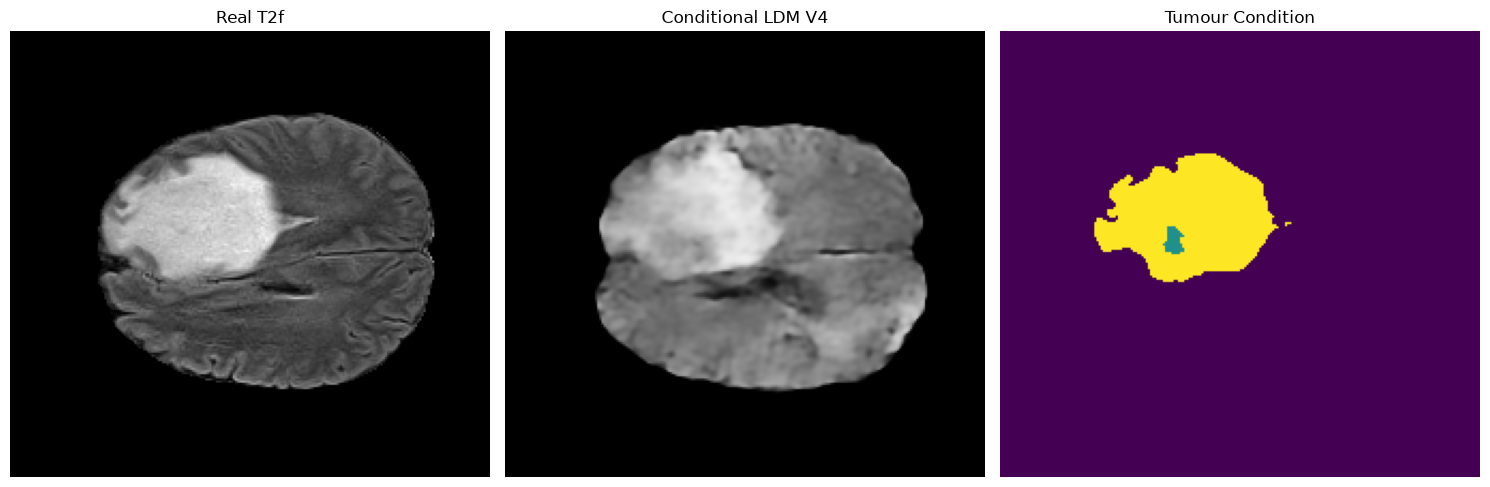

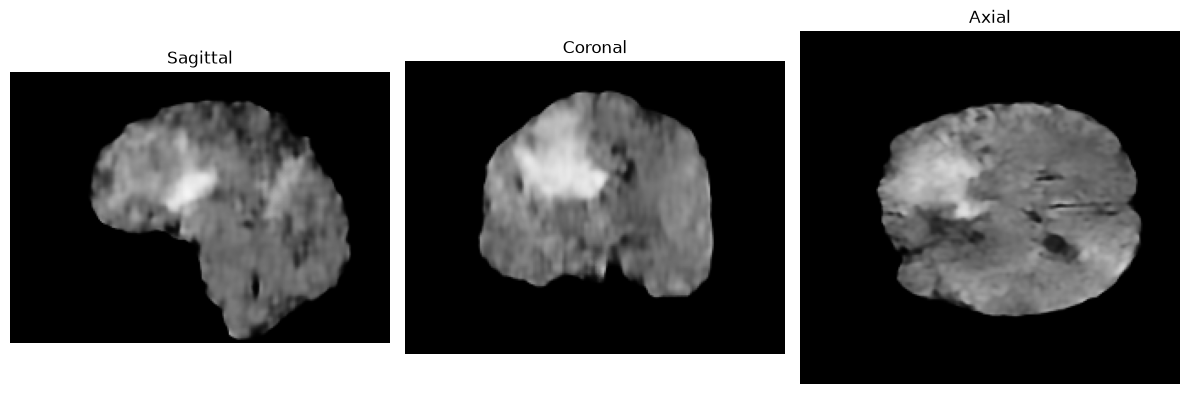


Generated statistics
Min: 7.793377e-11
Max: 0.97691035
Mean: 0.08567946
Std: 0.18593681


In [27]:
import matplotlib.pyplot as plt

# ============================================================
# Conditional LDM V5 - Final Sampling
# ============================================================

final_checkpoint = (
    "conditional_ldm_v5_checkpoints/"
    "conditional_ldm_v5_epoch_200.pt"
)


loaded_epoch = (
    load_ldm_checkpoint(
        model=model,
        ema=ema,
        optimizer=optimizer,
        path=final_checkpoint,
        device=device
    )
)


print(
    "Loaded V5 final epoch:",
    loaded_epoch
)


assert (
    loaded_epoch == 200
)


sample = (
    train_dataset[0]
)


real_image = (
    sample["image"]
    .unsqueeze(0)
    .to(device)
)


mask = (
    sample["mask"]
    .unsqueeze(0)
    .to(device)
)


entropy = (
    sample["heterogeneity"]
    .unsqueeze(0)
    .to(device)
)


print(
    "Subject:",
    sample["subject"]
)


print(
    "Raw entropy:",
    entropy.item()
)


# ============================================================
# V5 sampling with CFG
# ============================================================

generated_image, generated_latent = (
    sample_conditional_ldm_v5(
        model=ema.ema_model,
        vae=vae,
        mask=mask,
        entropy=entropy,
        device=device,
        seed=42,
        guidance_scale=1.5
    )
)


print(
    "CFG guidance scale:",
    1.5
)


print(
    "Generated image shape:",
    generated_image.shape
)


print(
    "Generated latent shape:",
    generated_latent.shape
)


print(
    "Generated range:",
    generated_image.min().item(),
    generated_image.max().item()
)


# ============================================================
# Convert to NumPy
# ============================================================

real_np = (
    real_image[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)


generated_np = (
    generated_image[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)


mask_np = (
    mask[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)


# VAE V3 output range is [0, 1]

real_display = np.clip(
    real_np,
    0.0,
    1.0
)


generated_display = np.clip(
    generated_np,
    0.0,
    1.0
)


# ============================================================
# Choose tumour-heavy axial slice
# ============================================================

tumour_per_slice = (
    mask_np > 0
).sum(
    axis=(0, 1)
)


tumour_slice = int(
    np.argmax(
        tumour_per_slice
    )
)


print(
    "Tumour slice:",
    tumour_slice
)


# ============================================================
# Real / Generated / Condition
# ============================================================

plt.figure(
    figsize=(15, 5)
)


plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    real_display[
        :,
        :,
        tumour_slice
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Real T2f"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    generated_display[
        :,
        :,
        tumour_slice
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Conditional LDM V5"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    mask_np[
        :,
        :,
        tumour_slice
    ],
    cmap="viridis"
)

plt.title(
    "Tumour Condition"
)

plt.axis(
    "off"
)


plt.tight_layout()
plt.show()


# ============================================================
# Orthogonal views
# ============================================================

x_mid = (
    generated_display.shape[0]
    // 2
)

y_mid = (
    generated_display.shape[1]
    // 2
)

z_mid = (
    generated_display.shape[2]
    // 2
)


plt.figure(
    figsize=(12, 4)
)


plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    generated_display[
        x_mid,
        :,
        :
    ].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.title(
    "Sagittal - V5"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    generated_display[
        :,
        y_mid,
        :
    ].T,
    cmap="gray",
    origin="lower",
    vmin=0,
    vmax=1
)

plt.title(
    "Coronal - V5"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    generated_display[
        :,
        :,
        z_mid
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Axial - V5"
)

plt.axis(
    "off"
)


plt.tight_layout()
plt.show()


# ============================================================
# Generated statistics
# ============================================================

print()
print(
    "Conditional LDM V5 "
    "generated statistics"
)


print(
    "Min:",
    generated_np.min()
)


print(
    "Max:",
    generated_np.max()
)


print(
    "Mean:",
    generated_np.mean()
)


print(
    "Std:",
    generated_np.std()
)

In [27]:
# ============================================================
# Conditional LDM V5 — Resume Pre-flight Check
# Does NOT start full training
# ============================================================

import os
import copy

print("=" * 72)
print("CONDITIONAL LDM V5 — RESUME PRE-FLIGHT CHECK")
print("=" * 72)


# ------------------------------------------------------------
# 1. Check V4 source checkpoint
# ------------------------------------------------------------

resume_checkpoint = (
    "conditional_ldm_v4_checkpoints/"
    "conditional_ldm_v4_epoch_050.pt"
)

assert os.path.exists(resume_checkpoint), (
    f"Missing checkpoint: {resume_checkpoint}"
)

print("V4 epoch-50 checkpoint found.")


# ------------------------------------------------------------
# 2. Load V4 epoch 50 into current V5-compatible architecture
# ------------------------------------------------------------

loaded_epoch = load_ldm_checkpoint(
    model=model,
    ema=ema,
    optimizer=optimizer,
    path=resume_checkpoint,
    device=device
)

print("Loaded epoch:", loaded_epoch)

assert loaded_epoch == 50

print("Checkpoint loading: PASS")


# ------------------------------------------------------------
# 3. Set V5 refinement LR
# ------------------------------------------------------------

for param_group in optimizer.param_groups:
    param_group["lr"] = 5e-5

print(
    "Resume LR:",
    optimizer.param_groups[0]["lr"]
)

assert abs(
    optimizer.param_groups[0]["lr"]
    - 5e-5
) < 1e-12

print("Learning rate: PASS")


# ------------------------------------------------------------
# 4. Verify next epoch numbering
# ------------------------------------------------------------

start_epoch = 50
end_epoch = 200

next_epoch_number = start_epoch + 1

print("Next epoch will be:", next_epoch_number)

assert next_epoch_number == 51

test_checkpoint_name = (
    f"conditional_ldm_v5_epoch_"
    f"{next_epoch_number:03d}.pt"
)

print(
    "First V5 checkpoint name:",
    test_checkpoint_name
)

assert (
    test_checkpoint_name
    == "conditional_ldm_v5_epoch_051.pt"
)

print("Epoch/checkpoint numbering: PASS")


# ------------------------------------------------------------
# 5. One real forward/backward step
# No optimizer.step()
# Therefore weights are NOT changed.
# ------------------------------------------------------------

model.train()
vae.eval()

batch = next(iter(train_loader))

x = batch["image"].to(
    device,
    non_blocking=True
)

mask = batch["mask"].to(
    device,
    non_blocking=True
)

entropy = batch[
    "heterogeneity"
].to(
    device,
    non_blocking=True
)

entropy = (
    entropy
    - ENTROPY_MEAN
) / ENTROPY_STD


latent_mean = LATENT_MEAN.to(device)
latent_std = LATENT_STD.to(device)


with torch.no_grad():

    mu, logvar = vae.encoder(x)

    z = (
        mu
        - latent_mean
    ) / latent_std


latent_mask = prepare_latent_mask(
    mask
)


t = torch.randint(
    0,
    timesteps,
    (z.shape[0],),
    device=device,
    dtype=torch.long
)

noise = torch.randn_like(z)

z_t = q_sample(
    z,
    t,
    noise
)

v_target = get_v_target(
    z,
    noise,
    t
)


optimizer.zero_grad(
    set_to_none=True
)


with torch.amp.autocast(
    device_type="cuda",
    enabled=(device.type == "cuda")
):

    v_pred = model(
        z_t,
        t,
        latent_mask,
        entropy
    )

    squared_error = (
        v_pred
        - v_target
    ) ** 2

    global_loss = (
        squared_error.mean()
    )


    tumour_region = (
        latent_mask.sum(
            dim=1,
            keepdim=True
        ) > 0
    )

    tumour_region = tumour_region.expand(
        -1,
        4,
        -1,
        -1,
        -1
    )


    if tumour_region.any():

        tumour_loss = (
            squared_error[
                tumour_region
            ].mean()
        )

    else:

        tumour_loss = torch.zeros(
            (),
            device=device,
            dtype=global_loss.dtype
        )


    loss = (
        global_loss
        + 0.25 * tumour_loss
    )


loss.backward()


print()
print("Forward/backward test")
print("Loss:", loss.item())
print("Global loss:", global_loss.item())
print("Tumour loss:", tumour_loss.item())
print("Prediction shape:", tuple(v_pred.shape))
print("Target shape:", tuple(v_target.shape))


assert torch.isfinite(loss)
assert v_pred.shape == z.shape
assert v_target.shape == z.shape


# Check actual gradient exists
grad_found = False

for parameter in model.parameters():

    if (
        parameter.grad is not None
        and torch.isfinite(
            parameter.grad
        ).all()
        and parameter.grad.abs().sum() > 0
    ):

        grad_found = True
        break


assert grad_found

print("Forward/backward: PASS")
print("Finite gradient: PASS")


# ------------------------------------------------------------
# IMPORTANT:
# no optimizer.step()
# so epoch-50 weights remain unchanged.
# ------------------------------------------------------------

optimizer.zero_grad(
    set_to_none=True
)


# ------------------------------------------------------------
# 6. Check V5 destination folder
# ------------------------------------------------------------

v5_dir = (
    "conditional_ldm_v5_checkpoints"
)

os.makedirs(
    v5_dir,
    exist_ok=True
)

print(
    "V5 output folder:",
    v5_dir
)

print(
    "V4 source folder remains:",
    "conditional_ldm_v4_checkpoints"
)

assert (
    v5_dir
    != "conditional_ldm_v4_checkpoints"
)

print("V4/V5 checkpoint separation: PASS")


print()
print("=" * 72)
print("FINAL RESULT")
print("=" * 72)

print("V4 epoch 50 loaded: PASS")
print("V5 architecture compatible: PASS")
print("Resume LR = 5e-5: PASS")
print("Next epoch = 51: PASS")
print("First V5 checkpoint = epoch_051: PASS")
print("Forward/backward: PASS")
print("V4/V5 folders separated: PASS")

print()
print(
    "Conditional LDM V5 is ready "
    "for resume training 51 -> 200."
)

CONDITIONAL LDM V5 — RESUME PRE-FLIGHT CHECK
V4 epoch-50 checkpoint found.
Loaded epoch: 50
Checkpoint loading: PASS
Resume LR: 5e-05
Learning rate: PASS
Next epoch will be: 51
First V5 checkpoint name: conditional_ldm_v5_epoch_051.pt
Epoch/checkpoint numbering: PASS

Forward/backward test
Loss: 0.5324468612670898
Global loss: 0.2824406027793884
Tumour loss: 1.0000250339508057
Prediction shape: (1, 4, 52, 56, 40)
Target shape: (1, 4, 52, 56, 40)
Forward/backward: PASS
Finite gradient: PASS
V5 output folder: conditional_ldm_v5_checkpoints
V4 source folder remains: conditional_ldm_v4_checkpoints
V4/V5 checkpoint separation: PASS

FINAL RESULT
V4 epoch 50 loaded: PASS
V5 architecture compatible: PASS
Resume LR = 5e-5: PASS
Next epoch = 51: PASS
First V5 checkpoint = epoch_051: PASS
Forward/backward: PASS
V4/V5 folders separated: PASS

Conditional LDM V5 is ready for resume training 51 -> 200.
